In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [3]:
df.shape

(7043, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


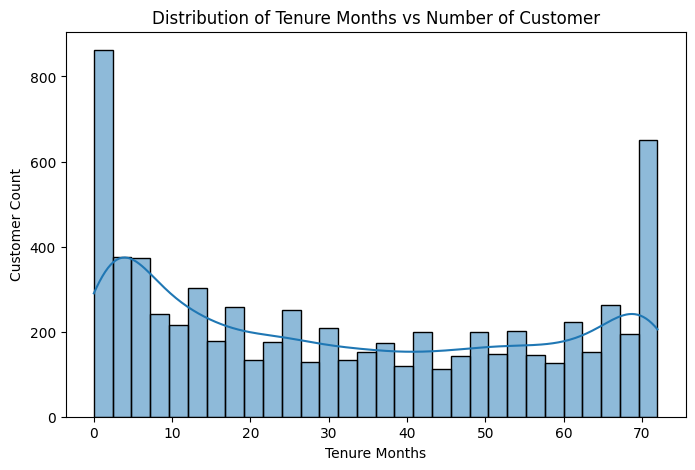

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins = 30, kde = True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer Count')
plt.title('Distribution of Tenure Months vs Number of Customer')
plt.show()

In [7]:
df['Tenure Months'].max()

72

In [8]:
df['Tenure Months'].min()

0

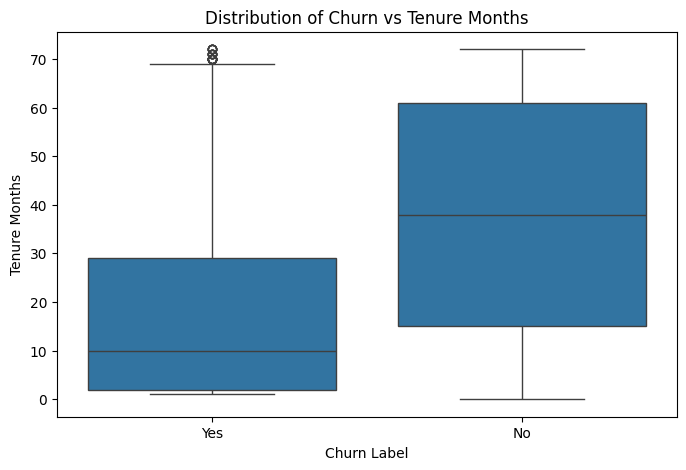

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months', data=df)
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Distribution of Churn vs Tenure Months')
plt.show()

In [10]:
df['Churn Label']=='Yes'

,Churn Label
0,True
1,True
2,True
3,True
4,True
...,...
7038,False
7039,False
7040,False
7041,False


In [11]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

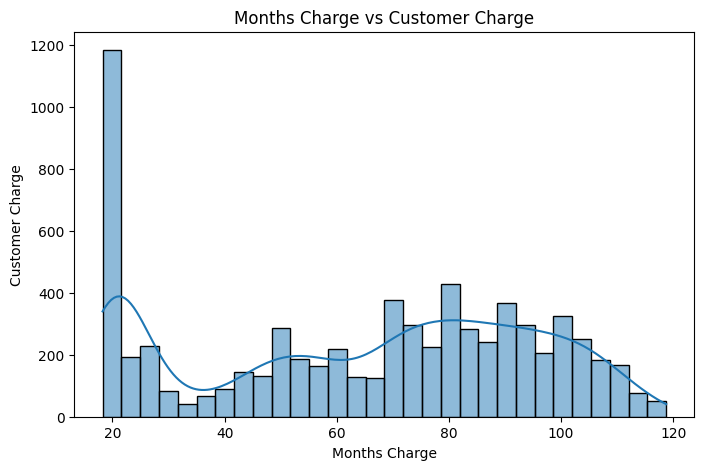

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins = 30, kde=True)
plt.xlabel('Months Charge')
plt.ylabel('Customer Charge')
plt.title('Months Charge vs Customer Charge')
plt.show()

In [13]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [14]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


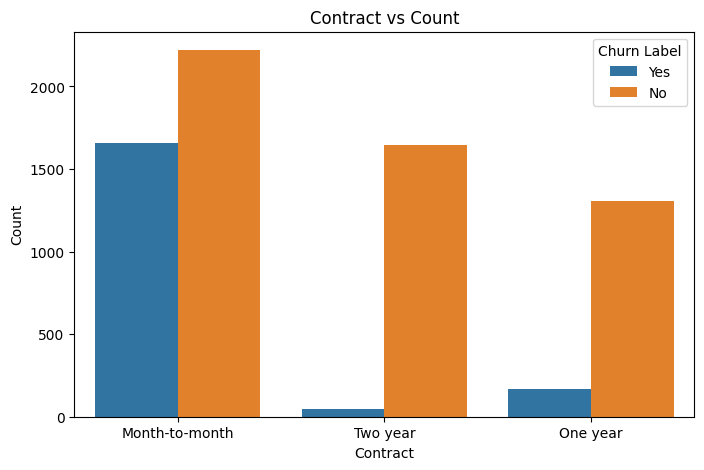

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data = df)
plt.xlabel('Contract')
plt.ylabel('Count')
plt.title('Contract vs Count')
plt.show()

In [16]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


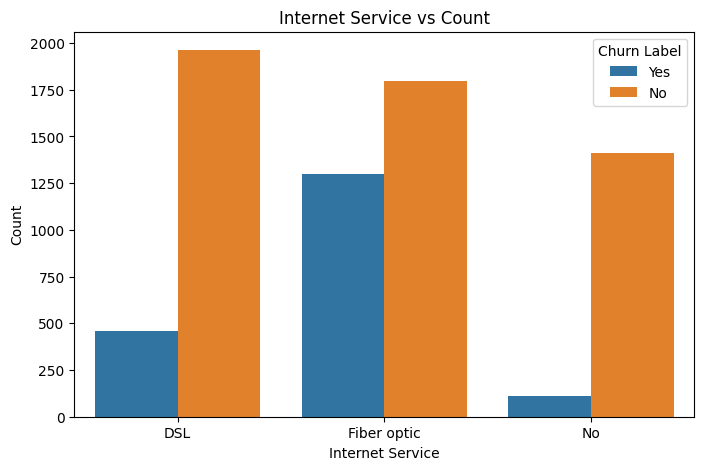

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data = df)
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.title('Internet Service vs Count')
plt.show()

In [18]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

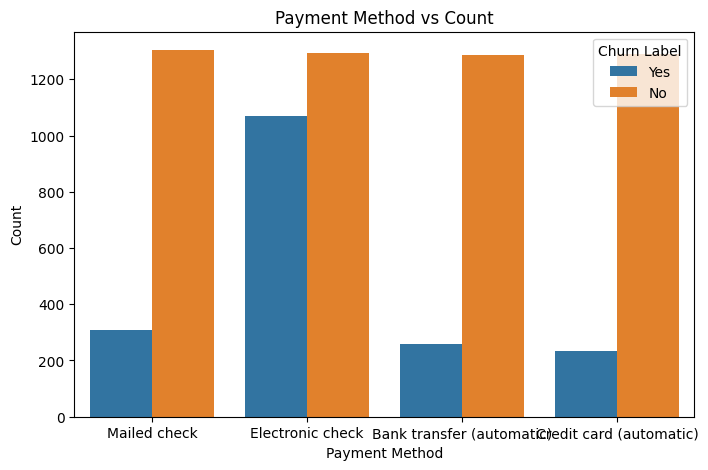

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', hue='Churn Label', data = df)
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.title('Payment Method vs Count')
plt.show()

In [20]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

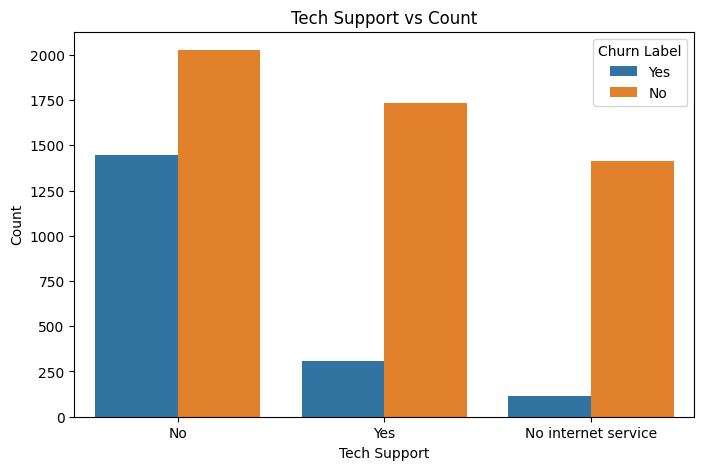

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support', hue='Churn Label', data = df)
plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.title('Tech Support vs Count')
plt.show()

In [22]:
avg_tenure = df.groupby("Churn Label")['Tenure Months'].mean()

In [23]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [24]:
numcolumns = ['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
corrmat = df[numcolumns].corr()

In [25]:
corrmat

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [26]:
ContractChurn = pd.crosstab(df['Contract'], df['Churn Label'])
ContractChurn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [27]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [28]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors = 'coerce')
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


In [29]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [30]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [31]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [32]:
df['Total Charges'] = df['Total Charges'].fillna(0)

In [33]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [34]:
drop_columns = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Label',
    'Churn Score',
    'CLTV',
    'Churn Reason'
]

In [35]:
df = df.drop(columns=drop_columns)

In [36]:
df.shape

(7043, 21)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [38]:
df_encoded = pd.get_dummies(df, drop_first = True)

In [39]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,City_Acton,City_Adelanto,City_Adin,City_Agoura Hills,City_Aguanga,City_Ahwahnee,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False


In [40]:
df_encoded.shape

(7043, 1159)

In [41]:
df = df.drop(columns=['City'])

In [42]:
df.shape

(7043, 20)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [44]:
df_encoded = pd.get_dummies(df, drop_first = True)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [47]:
df_encoded.shape

(7043, 31)

In [48]:
X=df_encoded.drop('Churn Value', axis=1)
Y=df_encoded['Churn Value']

In [49]:
X.shape
Y.shape

(7043,)

In [50]:
print(X)

      Tenure Months  Monthly Charges  Total Charges  Gender_Male  \
0                 2            53.85         108.15         True   
1                 2            70.70         151.65        False   
2                 8            99.65         820.50        False   
3                28           104.80        3046.05        False   
4                49           103.70        5036.30         True   
...             ...              ...            ...          ...   
7038             72            21.15        1419.40        False   
7039             24            84.80        1990.50         True   
7040             72           103.20        7362.90        False   
7041             11            29.60         346.45        False   
7042             66           105.65        6844.50         True   

      Senior Citizen_Yes  Partner_Yes  Dependents_Yes  Phone Service_Yes  \
0                  False        False           False               True   
1                  False       

In [51]:
print(Y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


***`Machine Learning Implementation`***


In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state = 42
)

In [54]:
from sklearn.ensemble import RandomForestClassifier

In [55]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [56]:
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [57]:
y_pred = rf_model.predict(X_test)

In [58]:
Y_test

,Churn Value
185,1
2715,0
3825,0
1807,1
132,1
...,...
6366,0
315,1
2439,0
5002,0


In [59]:
y_pred

array([0, 0, 0, ..., 1, 0, 1])

In [60]:
from sklearn.metrics import accuracy_score

In [61]:
accuracy = accuracy_score(Y_test,y_pred)

In [62]:
print(accuracy)

0.7856635911994322


In [63]:
from sklearn.metrics import confusion_matrix

In [64]:
cm = confusion_matrix(Y_test, y_pred)

In [65]:
print(cm)

[[902 107]
 [195 205]]


In [66]:
from sklearn.metrics import classification_report

In [67]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



# Approach 1 -Handle class ***imbalance***

In [68]:
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight = "balanced", random_state=42)

In [69]:
rf_balanced.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [70]:
y_pred_balanced = rf_balanced.predict(X_test)

In [71]:
accuracy_balanced = accuracy_score(Y_test, y_pred_balanced)

In [72]:
cm_balanced = confusion_matrix(Y_test, y_pred_balanced)

In [73]:
print(accuracy_balanced, cm_balanced, classification_report(Y_test, y_pred_balanced))

0.7920511000709723 [[907 102]
 [191 209]]               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



# ***Approach 2 - Hyperparameter Tuning***

In [74]:
rf_tuned = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight = "balanced", random_state=42)
rf_tuned.fit(X_train, Y_train)
y_pred_tuned = rf_tuned.predict(X_test)
print(classification_report(Y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



# ***Approach 3 feature importance analysis***

In [75]:
import pandas as pd
feature_importance = pd.DataFrame({
    'Features' : X.columns,
    'Importance' : rf_tuned.feature_importances_
})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

                                  Features  Importance
0                            Tenure Months    0.179069
2                            Total Charges    0.136460
25                       Contract_Two year    0.102861
1                          Monthly Charges    0.093681
6                           Dependents_Yes    0.068517
10            Internet Service_Fiber optic    0.060228
28         Payment Method_Electronic check    0.046732
24                       Contract_One year    0.036682
13                     Online Security_Yes    0.029356
19                        Tech Support_Yes    0.021106
26                   Paperless Billing_Yes    0.018064
5                              Partner_Yes    0.015846
12     Online Security_No internet service    0.014973
18        Tech Support_No internet service    0.014799
22    Streaming Movies_No internet service    0.014360
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3         

In [76]:
print(feature_importance.tail(15))

                                  Features  Importance
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3                              Gender_Male    0.012586
15                       Online Backup_Yes    0.012213
9                       Multiple Lines_Yes    0.011690
14       Online Backup_No internet service    0.010298
4                       Senior Citizen_Yes    0.010257
20        Streaming TV_No internet service    0.010186
23                    Streaming Movies_Yes    0.010161
27  Payment Method_Credit card (automatic)    0.009430
21                        Streaming TV_Yes    0.009289
17                   Device Protection_Yes    0.009101
29             Payment Method_Mailed check    0.008800
7                        Phone Service_Yes    0.003872
8          Multiple Lines_No phone service    0.003725


In [77]:
X_selected = X.drop(['Phone Service_Yes','Multiple Lines_No phone service'], axis=1)

In [78]:
X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(
    X_selected, Y, test_size=0.2, random_state = 42
)

In [79]:
rf_selected = RandomForestClassifier(n_estimators=300, max_depth=10,random_state=42,class_weight='balanced')
rf_selected.fit(X_train_sel, Y_train_sel)
y_pred_selected = rf_selected.predict(X_test_sel)
print(classification_report(Y_test, y_pred_selected))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [80]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

In [81]:

n_estimators_list = [100,200,300,400,500]
max_depth_list = [5,10,15,20]
results = []
for n_trees in n_estimators_list:
  for depth in max_depth_list:
    rf = RandomForestClassifier(n_estimators=n_trees, max_depth=depth, random_state=42, class_weight='balanced')
    rf.fit(X_train, Y_train)
    # y_pred = rf.predict(X_train,Y_train)
    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(Y_test, y_pred)
    recall = recall_score(Y_test, y_pred)
    precision = precision_score(Y_test, y_pred)
    f1=f1_score(Y_test,y_pred)
    results.append({'Trees':n_trees, 'Depth':depth, 'Accuracy':accuracy, 'Recall':recall, 'Precision':precision, 'F1':f1})
result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by=['Recall','Accuracy'], ascending=False)
print(result_df.head(20))

    Trees  Depth  Accuracy  Recall  Precision        F1
0     100      5  0.745919  0.8200   0.534202  0.646943
8     300      5  0.743790  0.8200   0.531605  0.645034
12    400      5  0.743790  0.8125   0.531915  0.642928
4     200      5  0.742370  0.8100   0.530278  0.640950
16    500      5  0.740951  0.8050   0.528736  0.638256
1     100     10  0.775727  0.7525   0.581081  0.655773
9     300     10  0.782825  0.7475   0.593254  0.661504
13    400     10  0.782825  0.7475   0.593254  0.661504
17    500     10  0.781405  0.7475   0.590909  0.660044
5     200     10  0.782115  0.7450   0.592445  0.660022
10    300     15  0.806246  0.6400   0.664935  0.652229
14    400     15  0.803407  0.6375   0.658915  0.648030
18    500     15  0.801987  0.6375   0.655527  0.646388
6     200     15  0.804826  0.6350   0.663185  0.648787
2     100     15  0.802697  0.6300   0.659686  0.644501
3     100     20  0.787793  0.5325   0.655385  0.587586
7     200     20  0.793471  0.5275   0.674121  0

In [82]:
from sklearn.model_selection import cross_val_score
final_rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')


In [83]:
cv_accuracy = cross_val_score(final_rf,X,Y,cv=5,scoring='accuracy')

In [84]:
cv_accuracy

array([0.76721079, 0.79772889, 0.76224273, 0.78551136, 0.78409091])

In [85]:
cv_accuracy.mean()

np.float64(0.7793569343183432)

In [86]:
cv_recall=cross_val_score(final_rf,X,Y,cv=5,scoring='recall')

In [87]:
cv_recall

array([0.70855615, 0.76470588, 0.74064171, 0.74331551, 0.71045576])

In [88]:
cv_recall.mean()

np.float64(0.7335350030823931)

In [89]:
from sklearn.metrics import roc_auc_score, roc_curve

In [90]:
import matplotlib.pyplot as plt

In [91]:
y_prob = rf_tuned.predict_proba(X_test)

In [92]:
churn_prob = y_prob[:,1]
fpr,tpr,threshold=roc_curve(Y_test,churn_prob)
auc_score=roc_auc_score(Y_test,churn_prob)
print(auc_score)

0.857104806739346


# ***CUSTOMER SEGMENTATION***

In [93]:
segmentation_data = pd.DataFrame({
    'Tenure Months':X_test['Tenure Months'],
    'Monthly Charges':X_test['Monthly Charges'],
    'Total Charges':X_test['Total Charges'],
    'Churn Probability':churn_prob
})

In [94]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
185,15,85.90,1269.55,0.716452
2715,18,56.80,1074.65,0.328659
3825,2,20.00,40.90,0.227716
1807,6,84.20,519.15,0.824308
132,40,104.80,4131.95,0.484764
...,...,...,...,...
6366,66,104.90,6891.45,0.120654
315,19,86.00,1532.45,0.711268
2439,2,90.35,190.50,0.709340
5002,68,110.20,7467.50,0.066674


In [95]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [96]:
scaled_data = scaler.fit_transform(segmentation_data)
print(scaled_data[:5])


[[-0.69631406  0.6691038  -0.45048988  1.14226737]
 [-0.57429095 -0.31419848 -0.53600108 -0.14949408]
 [-1.22508089 -1.55768728 -0.98955267 -0.48574109]
 [-1.0623834   0.61166002 -0.77972336  1.50154256]
 [ 0.32054522  1.30774342  0.80537089  0.37050095]]


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

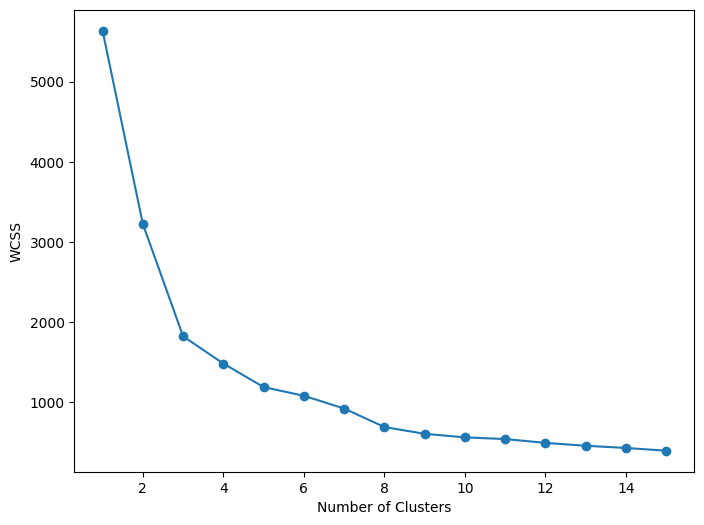

In [97]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1,16):
  kmeans = KMeans(n_clusters = k, random_state = 42,)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker = 'o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [98]:
kmeans = KMeans(n_clusters = 3, random_state = 42)

In [99]:
clusters = kmeans.fit_predict(scaled_data)

In [100]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
185,15,85.90,1269.55,0.716452
2715,18,56.80,1074.65,0.328659
3825,2,20.00,40.90,0.227716
1807,6,84.20,519.15,0.824308
132,40,104.80,4131.95,0.484764
...,...,...,...,...
6366,66,104.90,6891.45,0.120654
315,19,86.00,1532.45,0.711268
2439,2,90.35,190.50,0.709340
5002,68,110.20,7467.50,0.066674


In [101]:
segmentation_data['Cluster']=clusters

In [102]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
185,15,85.90,1269.55,0.716452,0
2715,18,56.80,1074.65,0.328659,2
3825,2,20.00,40.90,0.227716,2
1807,6,84.20,519.15,0.824308,0
132,40,104.80,4131.95,0.484764,1
...,...,...,...,...,...
6366,66,104.90,6891.45,0.120654,1
315,19,86.00,1532.45,0.711268,0
2439,2,90.35,190.50,0.709340,0
5002,68,110.20,7467.50,0.066674,1


In [103]:
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [104]:
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,11.118738,73.754082,904.016234,0.686490
1,58.807059,90.628588,5332.039529,0.227215
2,32.067416,33.397978,1083.450899,0.134227


In [105]:
cluster_names = {
    0:'Budget Loyal Customers',
    1:'High Risk New Customers',
    2:'Loyal Premium Customers',
}

In [106]:
segmentation_data['Cluster Segment']=segmentation_data['Cluster'].map(cluster_names)

In [107]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
185,15,85.90,1269.55,0.716452,0,Budget Loyal Customers
2715,18,56.80,1074.65,0.328659,2,Loyal Premium Customers
3825,2,20.00,40.90,0.227716,2,Loyal Premium Customers
1807,6,84.20,519.15,0.824308,0,Budget Loyal Customers
132,40,104.80,4131.95,0.484764,1,High Risk New Customers
...,...,...,...,...,...,...
6366,66,104.90,6891.45,0.120654,1,High Risk New Customers
315,19,86.00,1532.45,0.711268,0,Budget Loyal Customers
2439,2,90.35,190.50,0.709340,0,Budget Loyal Customers
5002,68,110.20,7467.50,0.066674,1,High Risk New Customers


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

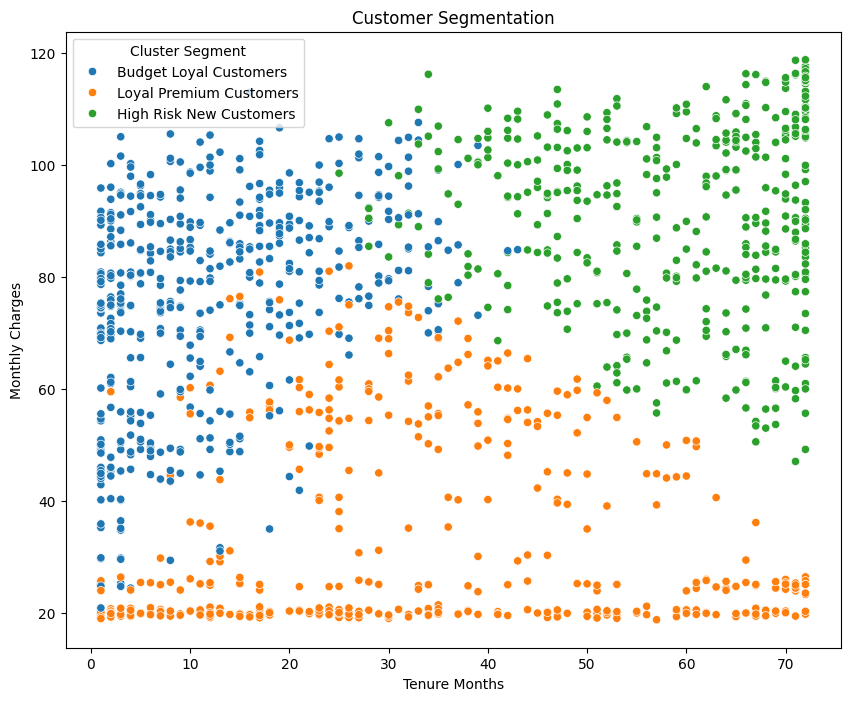

In [108]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Tenure Months',y='Monthly Charges',hue='Cluster Segment',data=segmentation_data)
plt.title('Customer Segmentation')
plt